In [1]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import dataclasses
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import itertools

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [3]:
metrics = []

In [4]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.enc1 = self.double_conv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = self.double_conv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.double_conv(1024, 512)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.double_conv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.double_conv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.double_conv(128, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        up4 = self.up4(bottleneck)
        dec4 = self.dec4(torch.cat([up4, enc4], dim=1))
        up3 = self.up3(dec4)
        dec3 = self.dec3(torch.cat([up3, enc3], dim=1))
        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, enc2], dim=1))
        up1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([up1, enc1], dim=1))

        return self.out_conv(dec1)

In [5]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [6]:
class Trainer:
    def __init__(self, config):
        self.config = config

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

        self.train_losses = []
        self.val_losses = []
        self.val_ious = []
        self.val_f1s = []

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.val_ious.append(val_iou)
            self.val_f1s.append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        self.plot_training()
        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")
        metrics.append([test_loss, test_iou, test_f1])

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()

    def plot_training(self):
            plt.figure(figsize=(12, 4))

            plt.subplot(1, 2, 1)
            plt.plot(self.train_losses, label='Train Loss', color='red')
            plt.plot(self.val_losses, label='Val Loss', color='blue')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.title('Loss Curves')
            plt.legend()

            plt.subplot(1, 2, 2)
            plt.plot(self.val_ious, label='IoU', color='green')
            plt.plot(self.val_f1s, label='F1-score', color='orange')
            plt.xlabel('Epoch')
            plt.ylabel('Score')
            plt.title('Validation Metrics')
            plt.legend()

            plt.tight_layout()
            plt.show()

In [7]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:21<00:00, 36.7MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 17.9MB/s]


100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 1 / 15, Train Loss: 0.4410, Val Loss: 0.3488, Val IoU: 0.8135, Val F1-score: 0.8897


100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


Epoch 2 / 15, Train Loss: 0.3175, Val Loss: 0.3349, Val IoU: 0.8212, Val F1-score: 0.8967


100%|██████████| 23/23 [00:12<00:00,  1.87it/s]


...

Epoch 13 / 15, Train Loss: 0.1177, Val Loss: 0.2411, Val IoU: 0.8609, Val F1-score: 0.9195


100%|██████████| 23/23 [00:12<00:00,  1.86it/s]


Epoch 14 / 15, Train Loss: 0.1194, Val Loss: 0.2303, Val IoU: 0.8699, Val F1-score: 0.9255


100%|██████████| 23/23 [00:12<00:00,  1.89it/s]


Epoch 15 / 15, Train Loss: 0.1093, Val Loss: 0.2007, Val IoU: 0.8871, Val F1-score: 0.9366


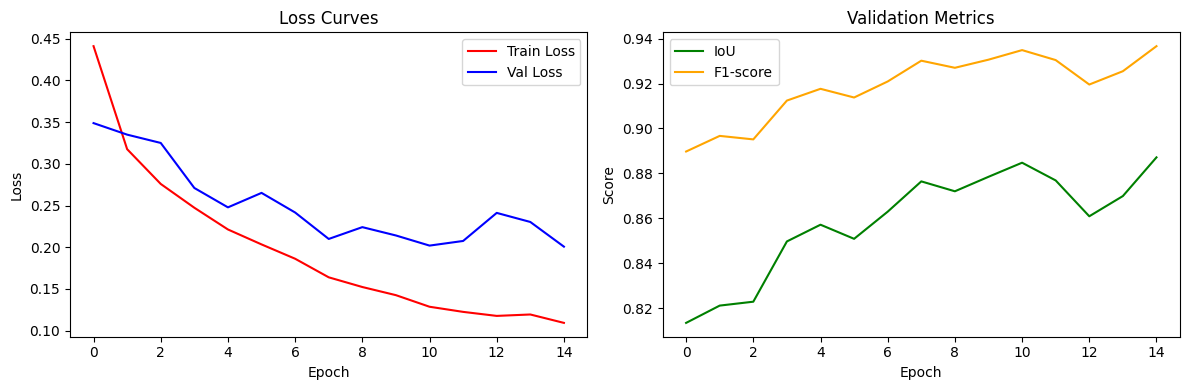

Testing...


100%|██████████| 115/115 [01:01<00:00,  1.86it/s]

Test Loss: 0.2103, Test IoU: 0.8849, Test F1-score: 0.9348


In [8]:
trainer.run()

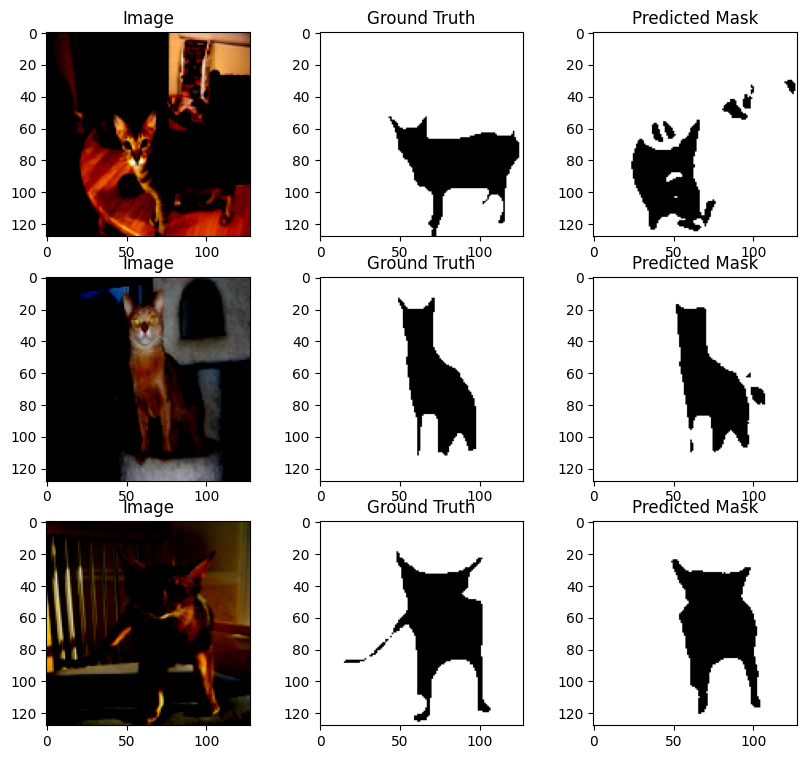

In [9]:
trainer.inference_and_plot_samples(n_samples=3)

In [10]:
def tune(base_config, param_grid, trial_epochs=5, p=2):
    keys = list(param_grid.keys())
    values = list(param_grid.values())
    combinations = list(itertools.product(*values))
    best_score = -1.0
    best_params = None

    print(f"Starting hyperparameter search")

    for idx, combo in enumerate(combinations):
        trial_params = dict(zip(keys, combo))
        print(f"\nTrial {idx+1}/{len(combinations)}: {trial_params}")
        trial_config = Config()
        for attr in dir(base_config):
            if not attr.startswith('_') and not callable(getattr(base_config, attr)):
                setattr(trial_config, attr, getattr(base_config, attr))
        for k, v in trial_params.items():
            setattr(trial_config, k, v)
        trial_config.epochs = trial_epochs

        trial_trainer = Trainer(trial_config)
        trial_trainer.transform = transforms.Compose([
            transforms.Resize(trial_config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
        ])
        trial_trainer.setup_dataloader()

        best_trial_iou = 0.0
        no_imp = 0
        for epoch in range(trial_epochs):
            trial_trainer.train()
            _, val_iou, _ = trial_trainer.validate()
            if val_iou > best_trial_iou:
                best_trial_iou = val_iou
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= p:
                    print(f"emergency stop after {epoch+1} epochs")
                    break

        print(f"Best IoU: {best_trial_iou:.4f}")

        if best_trial_iou > best_score:
            best_score = best_trial_iou
            best_params = trial_params

    final_config = Config()
    for attr in dir(base_config):
        if not attr.startswith('_') and not callable(getattr(base_config, attr)):
            setattr(final_config, attr, getattr(base_config, attr))
    for k, v in best_params.items():
        setattr(final_config, k, v)

    print(f"\nSearch completed. Best params: {best_params} (IoU: {best_score:.4f})")
    return final_config

In [11]:
param_grid = {
    'learning_rate': [0.001, 0.0001, 0.00001],
    'batch_size': [16, 32]
}

In [12]:
best_config = tune(config, param_grid, trial_epochs=5, p=2)

Starting hyperparameter search

Trial 1/6: {'learning_rate': 0.001, 'batch_size': 16}


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:14<00:00,  3.25it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Best IoU: 0.8458

Trial 2/6: {'learning_rate': 0.001, 'batch_size': 32}


100%|██████████| 23/23 [00:12<00:00,  1.81it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Best IoU: 0.8433

Trial 3/6: {'learning_rate': 0.0001, 'batch_size': 16}


...

Best IoU: 0.8581

Trial 5/6: {'learning_rate': 1e-05, 'batch_size': 16}


100%|██████████| 46/46 [00:13<00:00,  3.53it/s]
/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


Best IoU: 0.8399

Trial 6/6: {'learning_rate': 1e-05, 'batch_size': 32}


100%|██████████| 23/23 [00:12<00:00,  1.84it/s]

Best IoU: 0.8233

Search completed. Best params: {'learning_rate': 0.0001, 'batch_size': 16} (IoU: 0.8681)


In [13]:
new_trainer = Trainer(best_config)
new_trainer.transform = transforms.Compose([
    transforms.Resize(best_config.image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
new_trainer.setup_dataloader()

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


100%|██████████| 46/46 [00:12<00:00,  3.55it/s]


Epoch 1 / 15, Train Loss: 0.4188, Val Loss: 0.3552, Val IoU: 0.7937, Val F1-score: 0.8778


100%|██████████| 46/46 [00:12<00:00,  3.54it/s]


Epoch 2 / 15, Train Loss: 0.3073, Val Loss: 0.2980, Val IoU: 0.8366, Val F1-score: 0.9060


100%|██████████| 46/46 [00:12<00:00,  3.55it/s]


...

Epoch 13 / 15, Train Loss: 0.1148, Val Loss: 0.1876, Val IoU: 0.8913, Val F1-score: 0.9388


100%|██████████| 46/46 [00:12<00:00,  3.56it/s]


Epoch 14 / 15, Train Loss: 0.1082, Val Loss: 0.2009, Val IoU: 0.8863, Val F1-score: 0.9362


100%|██████████| 46/46 [00:12<00:00,  3.61it/s]


Epoch 15 / 15, Train Loss: 0.1028, Val Loss: 0.1805, Val IoU: 0.8960, Val F1-score: 0.9421


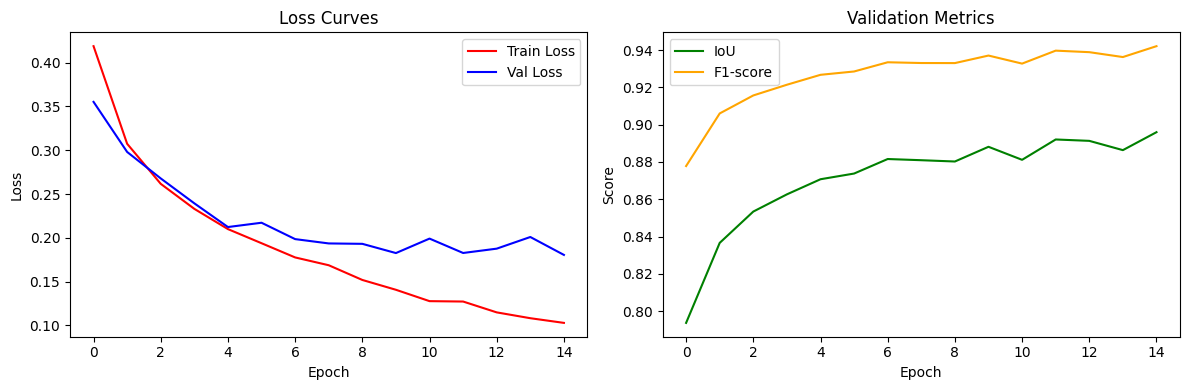

Testing...


100%|██████████| 230/230 [01:07<00:00,  3.42it/s]

Test Loss: 0.1909, Test IoU: 0.8933, Test F1-score: 0.9396


In [14]:
new_trainer.run()

Test Results:
Base Model: IoU = 0.8849, F1 = 0.9348
Tuned Model:   IoU = 0.8933, F1 = 0.9396


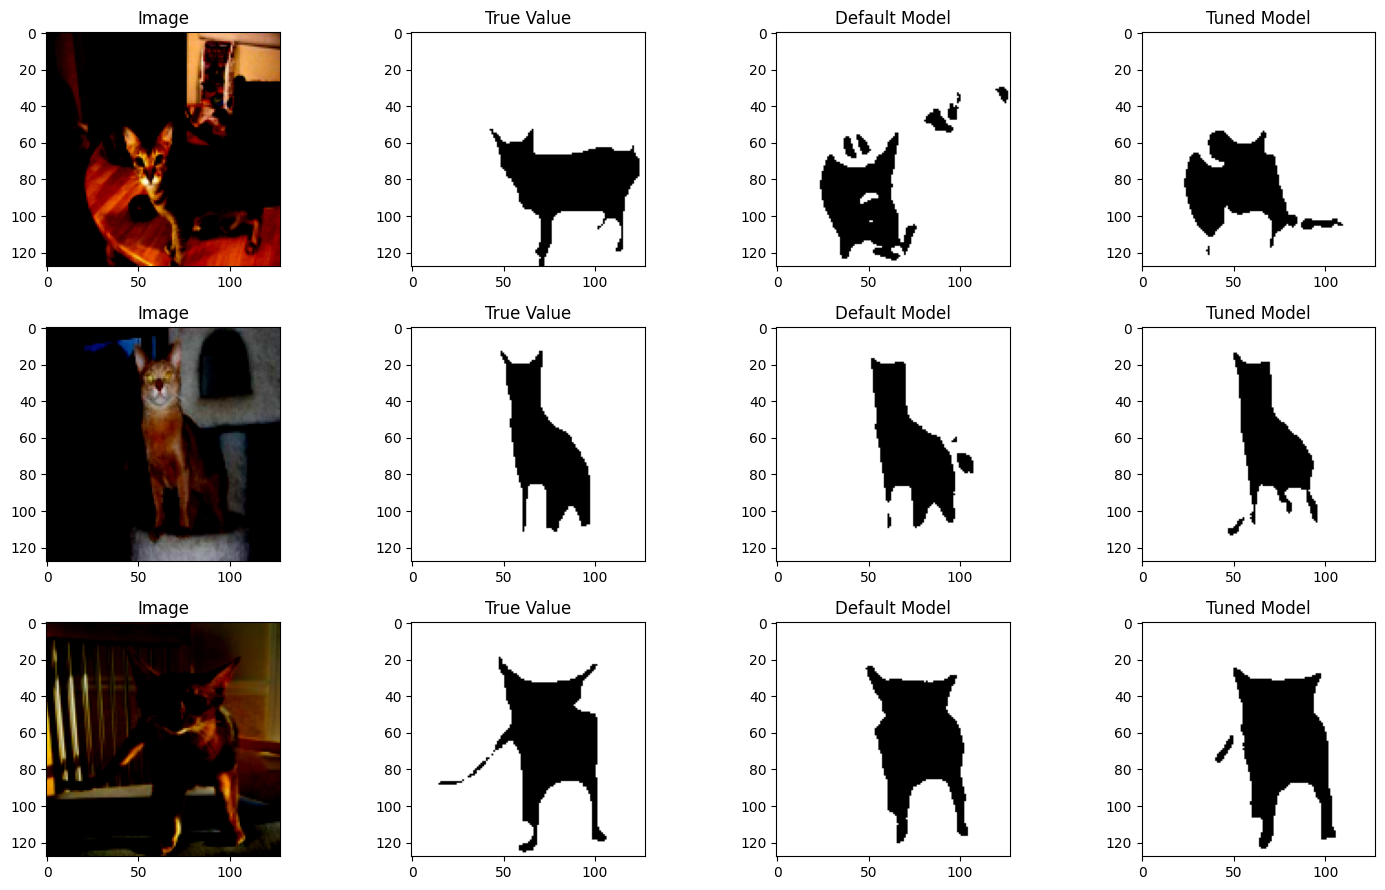

In [15]:
def compare_models(model1, model2, test_dataset, device, n_samples=3):
    model1.eval()
    model2.eval()
    iou1, f11 = evaluate_model(model1, test_dataset, device)
    iou2, f12 = evaluate_model(model2, test_dataset, device)

    print("Test Results:")
    print(f"Base Model: IoU = {iou1:.4f}, F1 = {f11:.4f}")
    print(f"Tuned Model:   IoU = {iou2:.4f}, F1 = {f12:.4f}")

    fig, axes = plt.subplots(n_samples, 4, figsize=(15, 3*n_samples))
    with torch.no_grad():
        for i in range(n_samples):
            img, mask = test_dataset[i]
            img_tensor = img.unsqueeze(0).to(device)
            out1 = torch.sigmoid(model1(img_tensor)).squeeze().cpu().numpy()
            out2 = torch.sigmoid(model2(img_tensor)).squeeze().cpu().numpy()
            pred1 = (out1 >= 0.5).astype(np.float32)
            pred2 = (out2 >= 0.5).astype(np.float32)

            axes[i, 0].imshow(img.permute(1,2,0).cpu())
            axes[i, 0].set_title("Image")
            axes[i, 1].imshow(mask.squeeze().cpu(), cmap='gray')
            axes[i, 1].set_title("True Value")
            axes[i, 2].imshow(pred1, cmap='gray')
            axes[i, 2].set_title("Default Model")
            axes[i, 3].imshow(pred2, cmap='gray')
            axes[i, 3].set_title("Tuned Model")
    plt.tight_layout()
    plt.show()

def evaluate_model(model, dataset, device):
    model.eval()
    ious, f1s = [], []
    with torch.no_grad():
        for i in range(len(dataset)):
            img, mask = dataset[i]
            img_tensor = img.unsqueeze(0).to(device)
            output = model(img_tensor)
            pred = (torch.sigmoid(output).squeeze().cpu().numpy() > 0.5).astype(np.uint8)
            mask_np = mask.squeeze().cpu().numpy().astype(np.uint8)
            ious.append(jaccard_score(mask_np.flatten(), pred.flatten(), average='binary'))
            f1s.append(f1_score(mask_np.flatten(), pred.flatten(), average='binary'))
    return np.mean(ious), np.mean(f1s)

compare_models(trainer.model, new_trainer.model, trainer.test_dataset, config.device, n_samples=3)

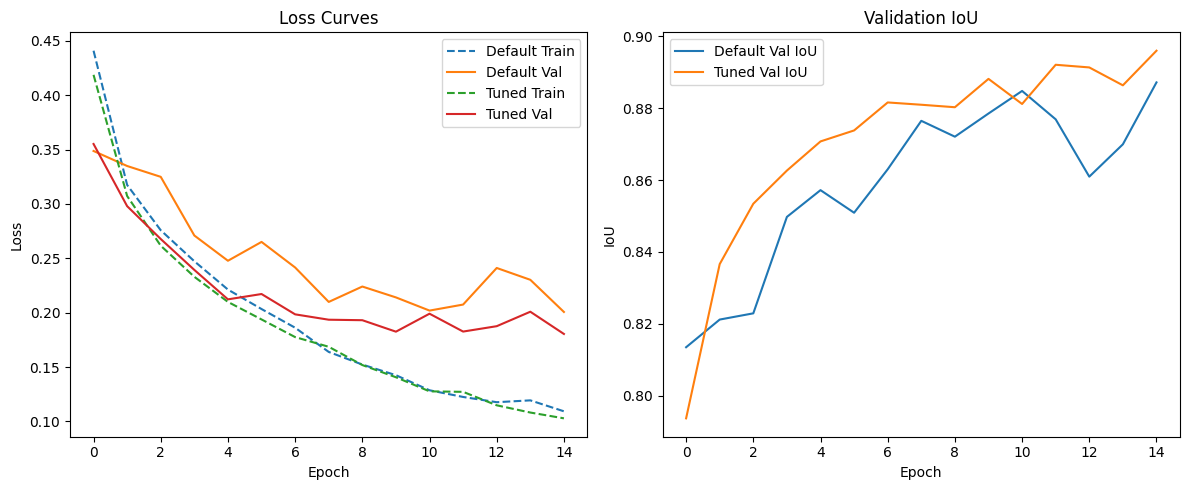

In [16]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trainer.train_losses, label='Default Train', linestyle='--')
plt.plot(trainer.val_losses, label='Default Val')
plt.plot(new_trainer.train_losses, label='Tuned Train', linestyle='--')
plt.plot(new_trainer.val_losses, label='Tuned Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trainer.val_ious, label='Default Val IoU')
plt.plot(new_trainer.val_ious, label='Tuned Val IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('Validation IoU')
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
class UNetDropout(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_prob=0.1):
        super(UNetDropout, self).__init__()

        self.enc1 = self.double_conv(in_channels, 64, dropout_prob)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128, dropout_prob)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256, dropout_prob)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512, dropout_prob)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = self.double_conv(512, 1024, dropout_prob)

        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = self.double_conv(1024, 512, dropout_prob)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = self.double_conv(512, 256, dropout_prob)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = self.double_conv(256, 128, dropout_prob)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = self.double_conv(128, 64, dropout_prob)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def double_conv(self, in_ch, out_ch, dropout_prob):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_prob),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout_prob)
        )

    def forward(self, x):
        enc1 = self.enc1(x)
        enc2 = self.enc2(self.pool1(enc1))
        enc3 = self.enc3(self.pool2(enc2))
        enc4 = self.enc4(self.pool3(enc3))

        bottleneck = self.bottleneck(self.pool4(enc4))

        up4 = self.up4(bottleneck)
        dec4 = self.dec4(torch.cat([up4, enc4], dim=1))
        up3 = self.up3(dec4)
        dec3 = self.dec3(torch.cat([up3, enc3], dim=1))
        up2 = self.up2(dec3)
        dec2 = self.dec2(torch.cat([up2, enc2], dim=1))
        up1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([up1, enc1], dim=1))

        return self.out_conv(dec1)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 46/46 [00:12<00:00,  3.58it/s]


Epoch 1 / 15, Train Loss: 0.4968, Val Loss: 0.3898, Val IoU: 0.7905, Val F1-score: 0.8777


100%|██████████| 46/46 [00:12<00:00,  3.57it/s]


Epoch 2 / 15, Train Loss: 0.3870, Val Loss: 0.3291, Val IoU: 0.8240, Val F1-score: 0.8982


100%|██████████| 46/46 [00:12<00:00,  3.58it/s]


...

Epoch 13 / 15, Train Loss: 0.1881, Val Loss: 0.1989, Val IoU: 0.8802, Val F1-score: 0.9327


100%|██████████| 46/46 [00:12<00:00,  3.64it/s]


Epoch 14 / 15, Train Loss: 0.1786, Val Loss: 0.1913, Val IoU: 0.8866, Val F1-score: 0.9373


100%|██████████| 46/46 [00:14<00:00,  3.15it/s]


Epoch 15 / 15, Train Loss: 0.1783, Val Loss: 0.2042, Val IoU: 0.8773, Val F1-score: 0.9313


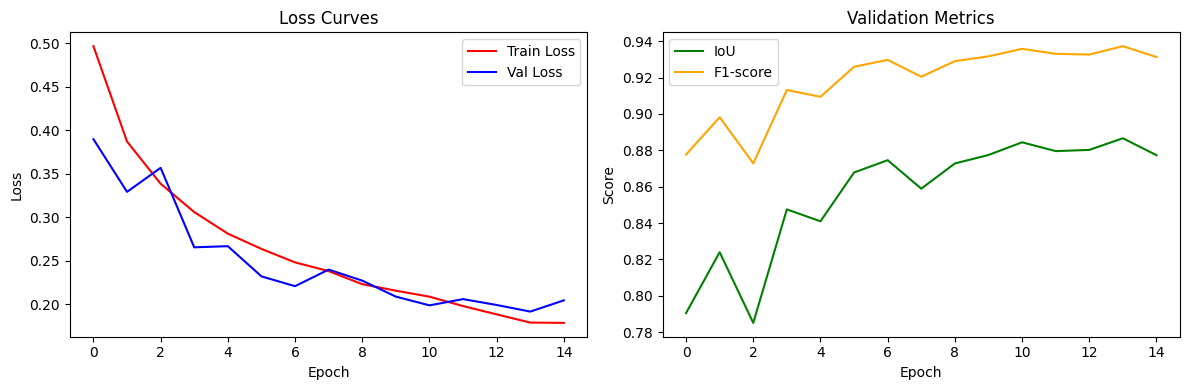

Testing...


100%|██████████| 230/230 [01:18<00:00,  2.94it/s]

Test Loss: 0.2069, Test IoU: 0.8742, Test F1-score: 0.9281


In [18]:
class TrainerDropout(Trainer):
    def __init__(self, config):
        super().__init__(config)
        self.model = UNetDropout().to(config.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

trainer_dropout = TrainerDropout(best_config)
trainer_dropout.transform = transforms.Compose([
    transforms.Resize(best_config.image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])
trainer_dropout.setup_dataloader()
trainer_dropout.run()

Test Results:
Base Model: IoU = 0.8849, F1 = 0.9348
Tuned Model:   IoU = 0.8742, F1 = 0.9281


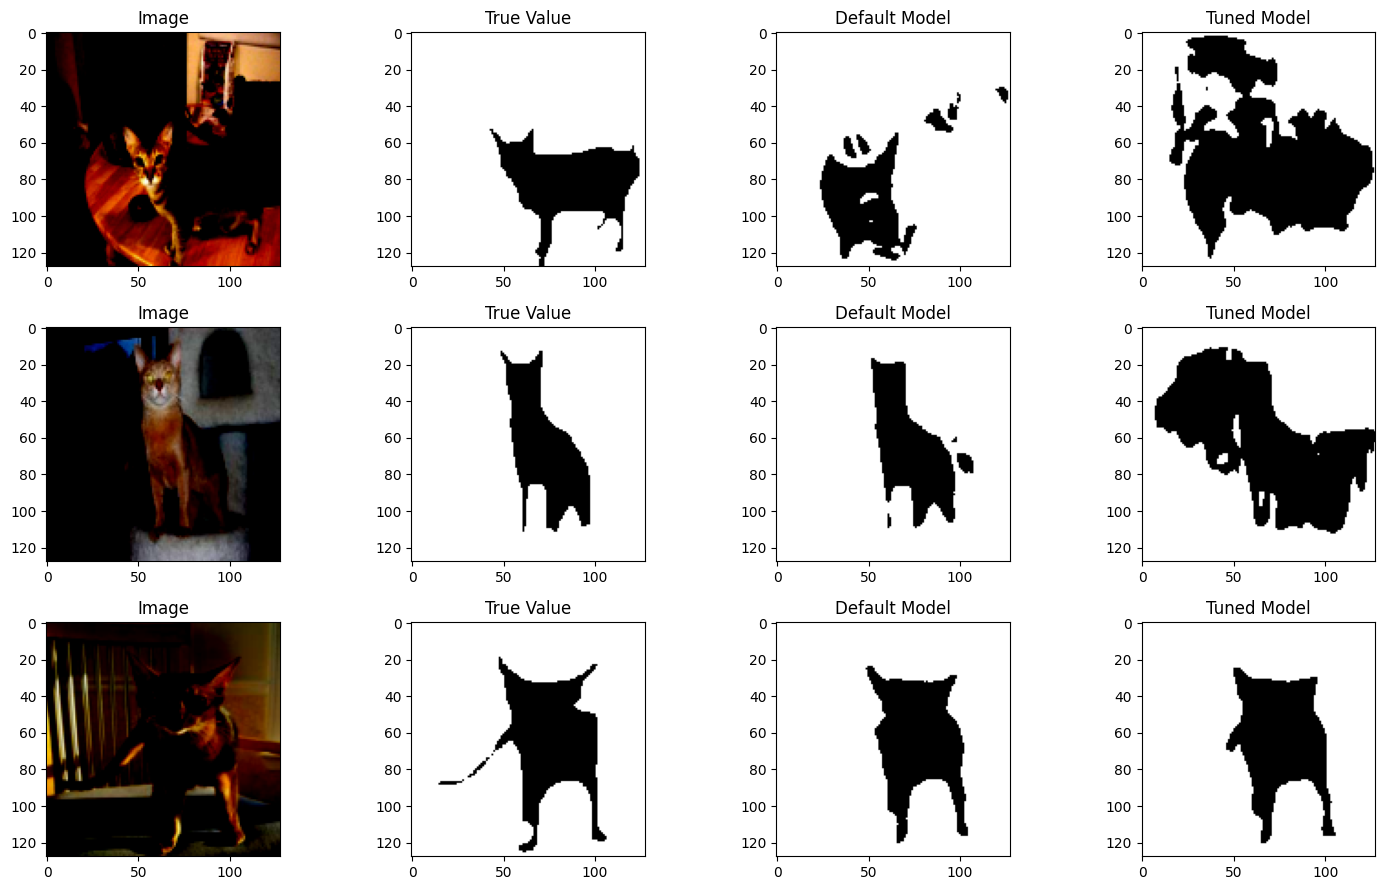

In [19]:
compare_models(trainer.model, trainer_dropout.model, trainer.test_dataset, config.device, n_samples=3)

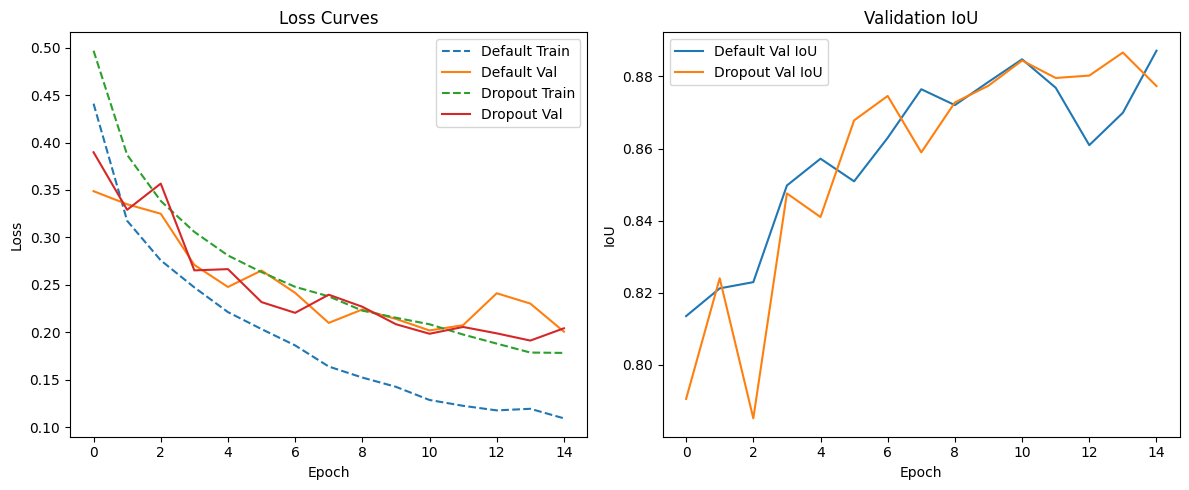

In [20]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(trainer.train_losses, label='Default Train', linestyle='--')
plt.plot(trainer.val_losses, label='Default Val')
plt.plot(trainer_dropout.train_losses, label='Dropout Train', linestyle='--')
plt.plot(trainer_dropout.val_losses, label='Dropout Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(trainer.val_ious, label='Default Val IoU')
plt.plot(trainer_dropout.val_ious, label='Dropout Val IoU')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.title('Validation IoU')
plt.legend()

plt.tight_layout()
plt.show()

Выводы

1. базовая модель так-то уже дала достаточно хорошие результаты, дополнительные улучшения имеют скорее учебный характер. Товарищи по группе говорят, что этот датасет сам по себе достаточно легкий - возможно, поэтому

2. При переборе гиперпараметров самым эффективным оказался batch-size 16, возможно из-за большего  количества шумов, которые позволяют эффективнее выбираться из локальных минимумов??? или из-за более частого обновления параметров

3. дропаут не дал значительного улучшения, возможно у базового юнета уже нормальная регуляризация + объём обучающей выборки недостаточно велик.